# EMNIST

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load train & test sets
train_data = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv')
test_data = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv')

# Separating labels and pixel features
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1].values

print(f"Training features shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (88799, 784)
Training labels shape: (88799,)
Testing features shape: (14799,)


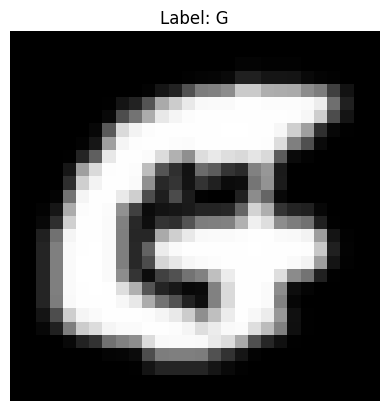

In [3]:
# Picking an index from the dataset (0 to 88798)
index = 0

# Reshape the 784 pixels to 28x28, then transpose it to fix the rotation
image = X_train[index].reshape(28,28).T

label_char = chr(y_train[index] + 64)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label_char}")
plt.axis('off')
plt.show()

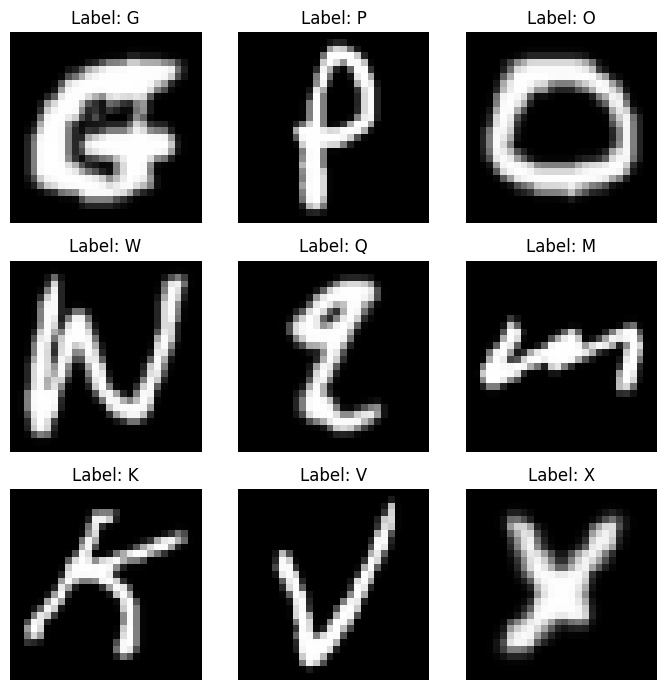

In [4]:
import matplotlib.pyplot as plt

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(7, 7))

# Loop through the first 9 images in the dataset
for i, ax in enumerate(axes.flat):
    # Reshape and transpose
    image = X_train[i].reshape(28, 28).T
    
    # Plot the image and set the title to the letter
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Label: {chr(y_train[i] + 64)}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Training a Binary Classifier

In [5]:
# Creating target vectors
y_train_F = (y_train == 6)
y_test_F = (y_test == 6)

# Creating a classifier & training it
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_F)

SGDClassifier(random_state=42)

In [6]:
# To detect images of F

f_index = np.where(y_train == 6)[0][0]
some_letter = X_train[f_index]
sgd_clf.predict([some_letter])

array([ True])

In [7]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_F, cv=3, scoring="accuracy")

array([0.95412162, 0.97091216, 0.96803946])

let’s look at a dummy classifier that just classifies every single image in the most frequent class, which in this case is the negative class (i.e., non F):

In [8]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_F)
print(any(dummy_clf.predict(X_train))) # prints False: no Fs detected

False


In [9]:
cross_val_score(dummy_clf, X_train, y_train_F, cv=3, scoring="accuracy")

array([0.96179054, 0.96175676, 0.96178925])

In [10]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_F, cv=3)

In [11]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_F, y_train_pred)

0.5429966203529853